---
title: Reproducible exploratory analysis - Mitigating multiplicity when mining data
project:
  type: website
format:
  html:
    code-fold: true
    code-tools: true
jupyter: python 3
number-sections: false
filters:
    - pyodide
---

Identifying meaningful patterns and relationships within noisy data is a fundamental component of neuroscience research; however, multiplicity - the practice of conducting multiple simultaneous comparisons - can result in spurious and misleading conclusions. Alternatively, strict approaches to correct for multiplicity can result in missed scientific conclusions. In this unit, learners will understand how multiplicity occurs, its impacts, and strategies to address it.

# 1 - Why mitigate multiplicity?

In science, it's common to test  data in multiple way. We might use our data to test multiple theories or we might test multiple features of data collected from a novel device.

After doing so, we often want to make confident statements about these test results. It's then important to deal with the challenges of **multiplicity**.

There are (at least) two common mistakes when confronting multiplicity:

1. **Too lenient**. If we do nothing about multiplicity in our results, then we might confuse spurious results occurring by chance with meaningful scientific conclusions.

2. **Too strict**. If we strictly address multiplicity, then - in our quest to avoid false positive results - we might disregard meaningful scientific conclusions.

Unfortunately, no one-size-fits-all solution exists to address multiplicity. For your data and your results, you'll need to make an informed decision.

Our goal in this unit is to practice making these decisions to address multiplicity, and explore the impact of being too lenient or too strict.


# 2 - Rat brains, position, and profit: an introduction to mitigating multiplicity

## The first suspicious scenario

Consider the following data mining scenario:

- A research group inserts tiny electrodes into a rodent brain and records the activity of individual neurons while the rat walks, eats, drinks, grooms, and sleeps.

- The researchers collect data from 76 neurons and then, from these 76 neurons, chooses 8 to analyze.

- The researchers report a handful of observations from the selected 8 neurons, such as how different neurons respond (i.e., generate action potentials) during some of the rat's different behaviors (e.g., during walking, during grooming).

::: {.callout-note}

## Approximately how many tests did these researchers perform?

<form id="quiz-form-tests">
    <input type="radio" name="answer_tests" value="incorrect1"> 76 tests<br>
    <input type="radio" name="answer_tests" value="incorrect2"> 81 tests<br>
    <input type="radio" name="answer_tests" value="correct"> 380 tests<br>
    <input type="radio" name="answer_tests" value="incorrect3"> 760 tests<br><br>
    <button type="button" onclick="checkAnswerTests()">Submit</button>
</form>

<p id="feedback_tests"></p>

<script>
function checkAnswerTests() {
    var selected = document.querySelector('input[name="answer_tests"]:checked');
    var feedback = document.getElementById("feedback_tests");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! The researchers performed approximately 380 tests, because 76 neurons × 5 behaviors = 380.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Not quite. That counts only the neurons, but each neuron was tested across 5 behaviors.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. This looks like adding 76 and 5, but the number of tests comes from multiplying neurons by behaviors.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. That is too high. Multiply 76 neurons by 5 behaviors: 76 × 5 = 380.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## Is this "good" scientific practice? Does anything concern you?

<form id="quiz-form-practice">
    <input type="radio" name="answer_practice" value="incorrect1"> Yes, this is definitely good scientific practice. Nothing concerns me.<br>
    <input type="radio" name="answer_practice" value="correct"> I do have a concern. I wonder why the researcher chose those 8 neurons to analyze during some of the rat’s behaviors.<br>
    <input type="radio" name="answer_practice" value="incorrect2"> No, because 8 neurons is always too small a sample to study.<br>
    <input type="radio" name="answer_practice" value="incorrect3"> No, because rats should not be studied during different behaviors.<br><br>
    <button type="button" onclick="checkAnswerPractice()">Submit</button>
</form>

<p id="feedback_practice"></p>

<script>
function checkAnswerPractice() {
    var selected = document.querySelector('input[name="answer_practice"]:checked');
    var feedback = document.getElementById("feedback_practice");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! A reasonable concern is whether the 8 neurons were selected in a principled way. If the researcher chose them selectively, that could bias the analysis.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Not quite. One concern is that the researcher analyzed only 8 neurons during some behaviors, and we should ask how those neurons were chosen.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Not necessarily. The main issue is not simply that 8 is a small number, but whether those 8 neurons were chosen fairly and without bias.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. Studying rats during different behaviors can be scientifically appropriate. The concern here is about the selection of the neurons analyzed.";
        feedback.style.color = "red";
    }
}
</script>

:::

## A second suspicious scenario

Consider this press release from another data mining scenario:

**EXTRA! EXTRA! RAT BRAINS CRACK THE STOCK MARKET CODE!**

*In a dazzling demonstration of rodent ingenuity—or perhaps sheer luck—[researchers have harnessed the firing neurons of rat motor cortices to predict movements in the U.S. stock market](https://improbable.com/airchives/paperair/volume12/v12i4/rats-12-4.pdf). That’s right, folks! A team from Michigan and Georgia linked rat brain activity to Wall Street ticker tapes, proving that whiskers may rival Wall Street wits. By monitoring the firing rates of 94 neurons across three rats, these scientists uncovered correlations between neural activity and the daily closing prices of stocks on NASDAQ, the NYSE, and the American Stock Exchange. The Coca-Cola stock price, for instance, danced in sync with the neurons like Fred and Ginger at the Ziegfeld Follies.*

*But wait, there’s more! The researchers didn’t stop at finding patterns — they dove headfirst into the trading floor with a predictive model based on neural firing rates. Rats’ neural spikes gave the orders: buy, sell, or hold. And the results? An impressive 43% increase in a simulated portfolio value, turning an initial \$1,000 investment into a snappy \$1,435 over just 20 trading days. Forget the contrarian strategies of hedge fund honchos—our furry friends seem to have cracked the code.*

*And here’s the kicker, folks: this isn’t just about making a buck. The findings suggest a mysterious connection between rat neural activity and human economic behavior. The researchers propose a grand theory linking the creatures of Earth to the ebbs and flows of societal urges, tying their work to theories like Gaia’s interconnected organism hypothesis. So, the next time someone says, “it’s a rat race out there,” remember—they might just be running the show!*

## So, what do we believe?

Using noisy data recorded from rodent brains, the two scenarios above report relationships between:

(1) the brain's neural activity and rodent behavior, and

(2) the brain's neural activity and the stock market.

**You might be (reasonably) skeptical.** How could neural activity from a rat brain possibly predict so many different things?

In what follows, we'll investigate this question with the goal of confronting the challenge of multiplicity. 



::: {.callout-note}

## When data mining, the number of relationships between the things you observe increases quickly with the number of observed items. To get a sense for this, consider observations from `N` neurons (e.g., spiking activity) and `M` signals (e.g., stock prices). How many possible combinations of relationships exist between the neurons and signals?

<form id="quiz-form-combinations">
    <input type="radio" name="answer_combinations" value="incorrect1"> `N + M`<br>
    <input type="radio" name="answer_combinations" value="correct"> `N * M`<br>
    <input type="radio" name="answer_combinations" value="incorrect2"> `N^M`<br>
    <input type="radio" name="answer_combinations" value="incorrect3"> `M / N`<br><br>
    <button type="button" onclick="checkAnswerCombinations()">Submit</button>
</form>

<p id="feedback_combinations"></p>

<script>
function checkAnswerCombinations() {
    var selected = document.querySelector('input[name="answer_combinations"]:checked');
    var feedback = document.getElementById("feedback_combinations");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! There are `N * M` possible neuron-signal relationships, because each of the `N` neurons can be paired with each of the `M` signals. This number can become very large very quickly.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. Adding `N` and `M` counts the total number of items, not the number of possible neuron-signal pairings.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Not quite. `N^M` grows much faster, but here we are simply counting all possible pairings between `N` neurons and `M` signals, which is `N * M`.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. Dividing `M` by `N` does not count combinations. The number of possible relationships is found by pairing each neuron with each signal: `N * M`.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## In the second suspicious scenario discussed above, activity from 94 neurons was compared with activity from 4195 stocks. How many possible combinations of relationships exist between the neurons and stock signals?

<form id="quiz-form-stock-combos">
    <input type="radio" name="answer_stock_combos" value="incorrect1"> 4,289<br>
    <input type="radio" name="answer_stock_combos" value="incorrect2"> 39,433<br>
    <input type="radio" name="answer_stock_combos" value="correct"> 394,330<br>
    <input type="radio" name="answer_stock_combos" value="incorrect3"> 381,745<br><br>
    <button type="button" onclick="checkAnswerStockCombos()">Submit</button>
</form>

<p id="feedback_stock_combos"></p>

<script>
function checkAnswerStockCombos() {
    var selected = document.querySelector('input[name="answer_stock_combos"]:checked');
    var feedback = document.getElementById("feedback_stock_combos");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! The number of possible neuron-stock relationships is 94 × 4195 = 394,330. That is a very large number of comparisons to examine.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. That is much too small. Each of the 94 neurons can be paired with each of the 4195 stocks, so you need to multiply.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. That is still far too small. The number of relationships is found by multiplying 94 by 4195.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Close, but not correct. Check the multiplication carefully: 94 × 4195 = 394,330, not 381,745.";
        feedback.style.color = "red";
    }
}
</script>

:::

# 2 - Visualization, our first analysis step

Motivated by these previous scenarios, you receive data from a collaborator interested in understanding the relationship between neural activity in the rodent brain, a measure of rodent behaviors (e.g., measures of the rodent's position, movement speed, head angle, etc.), and stock prices on the NYSE. The data consist of the following information:

* `spikes`  - the action potentials (or "spikes") generated by 200 neurons,

* `signals` - the rodent position (one of the signals) and the price of 99 stocks.

Both the `spikes` and `signals` are recorded simultaneously, every 10 ms for 0.5 s, resulting in a total of 500 time points.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import requests
# Load custom functions
url = "https://raw.githubusercontent.com/Mark-Kramer/METER-Units/refs/heads/main/exploratory_functions-SHORT.py"
response = requests.get(url)
exec(response.text)
spikes, signals, t = load_data()

print(response.text)

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm

def load_data():
    import pandas as pd
    df = pd.read_csv("https://raw.githubusercontent.com/Mark-Kramer/METER-Units/refs/heads/main/rodent_data.csv")
    spikes  = df.iloc[:, 0:200].to_numpy()
    signals = df.iloc[:, 200:300].to_numpy()
    t       = df.iloc[:, 300].to_numpy()
    return spikes, signals, t

def plot_spike_train(t, spikes):
    indices = [i for i, value in enumerate(spikes) if value == 1]; values  = [1] * len(indices)
    plt.plot(t[indices], values, 'ko');

def compute_p_values(spikes, signals):
    n1 = signals.shape[1]
    n2 = spikes.shape[1]
    p = np.zeros((n1, n2))

    for i in tqdm(range(n1)):       # tqdm shows the progress bar
        for j in range(n2):
                                    # GLM fitting with a Poisson family
            X = signals[:, i]       # Predictor variable
            y = spikes[:, j]        # Response v

We're interested in understanding the relationship (if any) between `spikes` and `signals`.

Let's start by investigating the structure of the data.

In [ ]:
print(spikes.shape)
print(signals.shape)

Both `spikes` and `signals` consist of 500 time points (the number of rows). We collect data from 200 neurons and 100 signals (the number of columns).

You might think of these variables as rectangles (or matrices), where each row indicates a time point, and each column indicates a neuron or signal:

![title](IMG_Exploratory/simple_boxes_neuron_and_signals.jpg)

Let's plot the data from one neuron in `spikes`:

In [ ]:
# Plot the spiking from an example neuron.
plt.figure(figsize=(12, 2))
plot_spike_train(t, spikes[:,0])  # Plot the first spike train.

::: {.callout-note}

## How do these data represent "spikes"?

<form id="quiz-form-spike-representation">
    <input type="radio" name="answer_spike_representation" value="correct"> In this signal, the value 1 means a spike occurs at time `t`, and the value 0 means no spike occurs at time `t`. The black circles indicate the times of spikes.<br>
    <input type="radio" name="answer_spike_representation" value="incorrect1"> In this signal, the value 1 means no spike occurs at time `t`, and the value 0 means a spike occurs at time `t`.<br>
    <input type="radio" name="answer_spike_representation" value="incorrect2"> The signal uses large values to show strong spikes and small values to show weak spikes.<br>
    <input type="radio" name="answer_spike_representation" value="incorrect3"> The black circles indicate missing data points rather than spikes.<br><br>
    <button type="button" onclick="checkAnswerSpikeRepresentation()">Submit</button>
</form>

<p id="feedback_spike_representation"></p>

<script>
function checkAnswerSpikeRepresentation() {
    var selected = document.querySelector('input[name="answer_spike_representation"]:checked');
    var feedback = document.getElementById("feedback_spike_representation");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! In these data, 1 means a spike occurs at time `t`, 0 means no spike occurs at time `t`, and the black circles mark the spike times.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. The coding is the other way around: 1 indicates that a spike occurs, and 0 indicates that no spike occurs.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. These data are represented in a binary way: 1 for a spike and 0 for no spike, rather than using larger values for stronger spikes.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. The black circles are used to show the times when spikes occur, not missing data.";
        feedback.style.color = "red";
    }
}
</script>

:::

Let's also plot the data from one signal in `signals`:

In [ ]:
# Plot the spiking from an example neuron.
plt.figure(figsize=(12, 2))
plt.plot(t, signals[:,0]);

::: {.callout-note}

## What features do you notice in the signal?

<form id="quiz-form-signal-features">
    <input type="radio" name="answer_signal_features" value="incorrect1"> The signal is perfectly smooth and has no noise.<br>
    <input type="radio" name="answer_signal_features" value="correct"> The signal is "wiggly" and may contain rhythmic oscillations, but it is noisy and hard to interpret clearly.<br>
    <input type="radio" name="answer_signal_features" value="incorrect2"> The signal is completely flat, so there is nothing to analyze.<br>
    <input type="radio" name="answer_signal_features" value="incorrect3"> The signal shows a perfectly regular rhythm with no uncertainty.<br><br>
    <button type="button" onclick="checkAnswerSignalFeatures()">Submit</button>
</form>

<p id="feedback_signal_features"></p>

<script>
function checkAnswerSignalFeatures() {
    var selected = document.querySelector('input[name="answer_signal_features"]:checked');
    var feedback = document.getElementById("feedback_signal_features");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! The signal appears wiggly and possibly rhythmic, but it is noisy enough that the pattern is not obvious with certainty.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. The signal is not perfectly smooth; one of the main features is that it looks noisy.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. The signal is not flat. It varies over time, which is why it looks wiggly.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Not quite. There may be some rhythmic structure, but the noise makes it hard to say the rhythm is perfectly regular.";
        feedback.style.color = "red";
    }
}
</script>

:::

To more directly compare the `spikes` and `signals`, let's plot one atop the other:

In [ ]:
plt.figure(figsize=(12, 2))
plt.plot(t, signals[:,0]);        # Plot the first signal.
plot_spike_train(t, spikes[:,0])  # Plot the first spike train.

::: {.callout-note}

## Compare the plots of example spiking and an example signal. Are they related?

<form id="quiz-form-signal-relationship">
    <input type="radio" name="answer_signal_relationship" value="incorrect1"> Yes, the relationship is obvious from visual inspection.<br>
    <input type="radio" name="answer_signal_relationship" value="correct"> It is very difficult to tell what relationship, if any, exists between the signals.<br>
    <input type="radio" name="answer_signal_relationship" value="incorrect2"> Yes, they are clearly unrelated.<br>
    <input type="radio" name="answer_signal_relationship" value="incorrect3"> The spiking plot causes the signal plot.<br><br>
    <button type="button" onclick="checkAnswerSignalRelationship()">Submit</button>
</form>

<p id="feedback_signal_relationship"></p>

<script>
function checkAnswerSignalRelationship() {
    var selected = document.querySelector('input[name="answer_signal_relationship"]:checked');
    var feedback = document.getElementById("feedback_signal_relationship");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! It is very difficult to tell from visual inspection what relationship, if any, exists between the spiking data and the signal.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. In this example, visual inspection is not especially useful, and any relationship is hard to determine by eye.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Not quite. The issue is not that they are clearly unrelated, but that it is difficult to tell whether any relationship exists at all.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. These plots do not show causation. The main point is that the relationship, if any, is hard to judge visually.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## We've used visual inspection to compare the spike train from one neuron (the first column of `spikes`) and one signal (the first column of `signals`). We didn't see an obvious relationship. However, there are many more relationships to compare. Repeat this analysis to compare each spike train (columns 1 to 200 of `spikes`) with each signal (columns 1 to 100 of `signals`). Do you observe any relationships?

<form id="quiz-form-many-plots">
    <input type="radio" name="answer_many_plots" value="incorrect1"> Yes, I can quickly visualize all of them and identify the meaningful relationships by eye.<br>
    <input type="radio" name="answer_many_plots" value="correct"> Wait! That's `100 * 200 = 20,000` plots to visualize ...<br>
    <input type="radio" name="answer_many_plots" value="incorrect2"> There are only 300 plots to check, so visual inspection is easy.<br>
    <input type="radio" name="answer_many_plots" value="incorrect3"> There are 2,000 plots, which is still manageable by eye.<br><br>
    <button type="button" onclick="checkAnswerManyPlots()">Submit</button>
</form>

<p id="feedback_many_plots"></p>

<script>
function checkAnswerManyPlots() {
    var selected = document.querySelector('input[name="answer_many_plots"]:checked');
    var feedback = document.getElementById("feedback_many_plots");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! Comparing 200 spike trains with 100 signals would require 20,000 plots, which is far too many to assess usefully by visual inspection.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. There are far too many comparisons to inspect one by one visually.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. You need to multiply 200 spike trains by 100 signals, giving 20,000 plots.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. The correct count is 200 × 100 = 20,000 plots, not 2,000.";
        feedback.style.color = "red";
    }
}
</script>

:::

<div class="alert alert-block alert-danger">
<b>Alert: We can't use visualization alone!</b>

</p>

- There are 200 neurons and 100 signals, resulting in 20,000 pairs to consider.

- We can't possibly visualize all of those.

- Instead, we need to perform statistical tests.
</div>

# 3- Profit! Rat brains for high-frequency trading in the NYSE

Let's now investigate the pairwise associations between the spiking of 200 neurons in the rat brain, the rat position, and 99 stock prices.

::: {.callout-note}

## We have 200 neurons and 100 signals. How many possible combinations of relationships exist between the neurons and signals?

<form id="quiz-form-200-100-combos">
    <input type="radio" name="answer_200_100_combos" value="incorrect1"> 300<br>
    <input type="radio" name="answer_200_100_combos" value="incorrect2"> 2,000<br>
    <input type="radio" name="answer_200_100_combos" value="correct"> 20,000<br>
    <input type="radio" name="answer_200_100_combos" value="incorrect3"> 200,000<br><br>
    <button type="button" onclick="checkAnswer200100Combos()">Submit</button>
</form>

<p id="feedback_200_100_combos"></p>

<script>
function checkAnswer200100Combos() {
    var selected = document.querySelector('input[name="answer_200_100_combos"]:checked');
    var feedback = document.getElementById("feedback_200_100_combos");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! There are 200 × 100 = 20,000 possible neuron-signal relationships. That is a large number of comparisons.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. Adding 200 and 100 gives 300, but the number of relationships is found by multiplying.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. That is too small. Each of the 200 neurons can be paired with each of the 100 signals, so the total is 20,000.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. That is too large. The correct calculation is 200 × 100 = 20,000.";
        feedback.style.color = "red";
    }
}
</script>

:::

To compare the `spikes` and `signals`, we perform a statisitcal test of the association between each pair of data. There are many choices you could make to assess the associations and perform the statistical tests. We will not investigate those choices here. Instead, we will perform a sophisticated - yet standard - approach to assess the relationship between the `spikes` and `signals`; if you're interested in (many) more analysis details, check out [this link](https://mark-kramer.github.io/Case-Studies-Python/09.html).

Again, for our purposes, the details of the test are not important.

What is important is that **each test produces a p-value** and we interpret small p-values to indicate statistically significant associations (**link to Unit:"Putting the p-value in Context"**).

Let's compute those p-values now. This step is slow, because there are many p-values to compute!

In [5]:
p = compute_p_values(spikes, signals)

100%|██████████| 100/100 [00:29<00:00,  3.37it/s]


For each neuron-signal pair, we estimate the association with an associated p-value.

We now have 20,000 p-values to investigate.

To start, let's visualize those p-values.

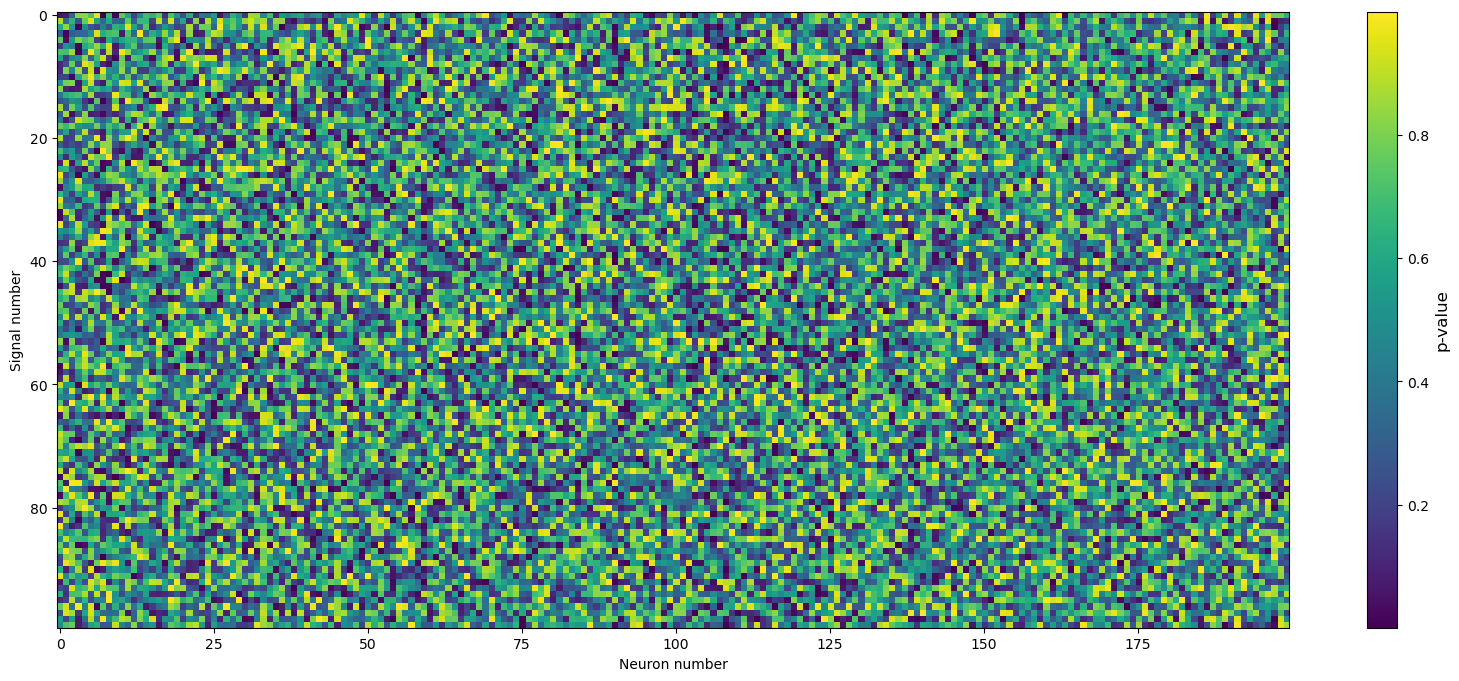

In [6]:
plt.figure(figsize=(20, 8))
plt.imshow(p); cbar = plt.colorbar(); cbar.set_label('p-value', fontsize=12)
plt.xlabel('Neuron number'); plt.ylabel('Signal number');

::: {.callout-note}

## What do you observe? Can you find the meaningful relationships between neurons and signals, if any?

<form id="quiz-form-meaningful-relationships">
    <input type="radio" name="answer_meaningful_relationships" value="incorrect1"> The darkest blue pixels clearly reveal all of the meaningful relationships.<br>
    <input type="radio" name="answer_meaningful_relationships" value="correct"> We’re looking for small values (the darkest blue) in the image. There appear to be many dark blue pixels, and it is very difficult to see the meaningful relationships. The image is noisy.<br>
    <input type="radio" name="answer_meaningful_relationships" value="incorrect2"> There are no dark blue pixels, so there are no relationships at all.<br>
    <input type="radio" name="answer_meaningful_relationships" value="incorrect3"> The image is clean and the meaningful relationships are easy to identify by eye.<br><br>
    <button type="button" onclick="checkAnswerMeaningfulRelationships()">Submit</button>
</form>

<p id="feedback_meaningful_relationships"></p>

<script>
function checkAnswerMeaningfulRelationships() {
    var selected = document.querySelector('input[name="answer_meaningful_relationships"]:checked');
    var feedback = document.getElementById("feedback_meaningful_relationships");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! We are looking for small values, shown as the darkest blue pixels. But there are many dark blue pixels, the image is noisy, and it is difficult to identify the meaningful relationships.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. Although the darkest blue pixels represent small values, there are many of them, so the meaningful relationships are not easy to identify.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. The issue is not that there are no dark blue pixels. The problem is that there are many of them, making the image noisy and hard to interpret.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. The image is noisy, so meaningful relationships are not easy to find by visual inspection.";
        feedback.style.color = "red";
    }
}
</script>

:::

To isolate meaningful relationships, let's count the number of associations in which p<0.05, the standard threshold for signficance applied in practice (**link to Unit:"Putting the p-value in Context"**).

In [8]:
np.sum(p < 0.05)

1104

::: {.callout-note}

## Interpret this result. What do you conclude about the data?

<form id="quiz-form-interpret-result">
    <input type="radio" name="answer_interpret_result" value="incorrect1"> We found exactly 20,000 meaningful associations between spikes and signals.<br>
    <input type="radio" name="answer_interpret_result" value="correct"> Of the 20,000 possible associations between spikes and signals, we detect 1104 associations with `p < 0.05`.<br>
    <input type="radio" name="answer_interpret_result" value="incorrect2"> There are no associations between spikes and signals.<br>
    <input type="radio" name="answer_interpret_result" value="incorrect3"> All 1104 detected associations must be truly meaningful.<br><br>
    <button type="button" onclick="checkAnswerInterpretResult()">Submit</button>
</form>

<p id="feedback_interpret_result"></p>

<script>
function checkAnswerInterpretResult() {
    var selected = document.querySelector('input[name="answer_interpret_result"]:checked');
    var feedback = document.getElementById("feedback_interpret_result");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! Of the 20,000 possible associations between spikes and signals, 1104 have `p < 0.05`.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. The result does not say that all 20,000 associations are meaningful. It says that 1043 of them have `p < 0.05`.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. The analysis detected 1043 associations with `p < 0.05`, so it is not true that there are no associations.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Not quite. The result says 1043 associations have `p < 0.05`, but that does not automatically mean they are all truly meaningful.";
        feedback.style.color = "red";
    }
}
</script>

:::

<div class="alert alert-block alert-info">

*Conclusion*:

- Rat brain neural activity seems to be associated with stock prices and the rodent's position!
- Let's develop a new strategy for profitable high-frequency stock trading using rat brain neuron spiking.

</div>

<div class="alert alert-block alert-info">

*Reflection*:

- Hmm, there are a lot of significant relationships - this was so easy!
- Why doesn't everyone use rat brain activity to predict the stock market?
</div>

<div class="alert alert-block alert-danger">
<b>Alert: Wait, this doesn't make sense!</b>

</p>

- How can the spike timing in a rat brain relate to stock market prices?

- We've conducted many (20,000 in fact) statistical tests and identified all associations with p<0.05 ... Is that the right choice?
</div>

# 4- Not so fast … finding meaningful relationships after you’ve tested everything.

In the previous section, we assessed associations between 200 neurons and 100 signals.

This exploration led to many (20,000) statistical tests.

When we compute so many tests, we need to **correct for multiplicity**.

**Important fact**: When conducting multiple hypothesis tests, increased error rates occur because each test has a chance of incorrectly rejecting the null hypothesis (a false positive). This error, typically called the **Type I error**, is the probability of a single test falsely claiming a statistically significant effect.

As more tests are performed, the cumulative probability of committing at least one Type I error across all these tests increases, leading to an overall higher error rate for the set of tests than for any individual test. This phenomenon is often referred to as the ["multiple comparisons problem"](https://en.wikipedia.org/wiki/Multiple_comparisons_problem) or "multiplicity."

**To mitigate multiplicity in our analysis**, we must account for increased error rates due to conducting multiple hypothesis tests on the same dataset.

::: {.callout-note}

## In our initial analysis, we found all p-values < 0.05. If we want to talk like a statistician, we'd say: *We chose a Type I error rate (`\alpha`) of 0.05.*

This means that each test has probability 0.05 of falsely claiming a statistically significant effect.

We performed 20,000 total tests. How many false statistically significant effects do we expect?

<form id="quiz-form-false-positives">
    <input type="radio" name="answer_false_positives" value="incorrect1"> 50<br>
    <input type="radio" name="answer_false_positives" value="incorrect2"> 100<br>
    <input type="radio" name="answer_false_positives" value="correct"> 1000<br>
    <input type="radio" name="answer_false_positives" value="incorrect3"> 1104<br><br>
    <button type="button" onclick="checkAnswerFalsePositives()">Submit</button>
</form>

<p id="feedback_false_positives"></p>

<script>
function checkAnswerFalsePositives() {
    var selected = document.querySelector('input[name="answer_false_positives"]:checked');
    var feedback = document.getElementById("feedback_false_positives");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! We expect 20,000 × 0.05 = 1000 false statistically significant effects. Since 1104 associations had `p < 0.05`, this suggests that most of them are likely false positives.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. That is far too small. You need to multiply the number of tests by the Type I error rate: 20,000 × 0.05 = 1000.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. That is too small. With 20,000 tests and `\\alpha = 0.05`, the expected number of false positives is 1000.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Not quite. 1104 is the number of observed associations with `p < 0.05`, not the expected number of false positives. The expected number is 20,000 × 0.05 = 1000.";
        feedback.style.color = "red";
    }
}
</script>

:::

## Intuition building aside

Imagine you have a fair coin and you flip it a few times. Let's think about what happens ...

::: {.callout-note}

## Flip 5 coins. Are you likely to get all heads?

<form id="quiz-form-five-coins">
    <input type="radio" name="answer_five_coins" value="correct"> No. That’s unlikely when you do it once.<br>
    <input type="radio" name="answer_five_coins" value="incorrect1"> Yes. You are likely to get all heads in one flip of 5 coins.<br>
    <input type="radio" name="answer_five_coins" value="incorrect2"> Yes. You will always get all heads if you flip carefully.<br>
    <input type="radio" name="answer_five_coins" value="incorrect3"> It is impossible to get all heads.<br><br>
    <button type="button" onclick="checkAnswerFiveCoins()">Submit</button>
</form>

<p id="feedback_five_coins"></p>

<script>
function checkAnswerFiveCoins() {
    var selected = document.querySelector('input[name="answer_five_coins"]:checked');
    var feedback = document.getElementById("feedback_five_coins");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! Getting all heads in 5 coin flips is possible, but it is unlikely if you do it only once.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. Getting all heads can happen, but it is not likely in a single set of 5 flips.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. Coin flips are random, so flipping carefully does not guarantee all heads.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. It is possible to get all heads, just not very likely in one try.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## Now, ask 1000 people to repeat this 5-coin-flip process. Do you think *someone* will get all heads?

<form id="quiz-form-many-people-coins">
    <input type="radio" name="answer_many_people_coins" value="correct"> Yes. By chance, someone might flip 5 coins and get all heads.<br>
    <input type="radio" name="answer_many_people_coins" value="incorrect1"> No. If getting all heads is unlikely for one person, it cannot happen for a group of 1000 people.<br>
    <input type="radio" name="answer_many_people_coins" value="incorrect2"> No. It is impossible for anyone to get all heads.<br>
    <input type="radio" name="answer_many_people_coins" value="incorrect3"> Yes. Every person will probably get all heads.<br><br>
    <button type="button" onclick="checkAnswerManyPeopleCoins()">Submit</button>
</form>

<p id="feedback_many_people_coins"></p>

<script>
function checkAnswerManyPeopleCoins() {
    var selected = document.querySelector('input[name="answer_many_people_coins"]:checked');
    var feedback = document.getElementById("feedback_many_people_coins");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! Even though all heads is unlikely for one person, with 1000 people trying, someone might get all heads just by chance. This is why accounting for multiplicity matters.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. An event can be unlikely for one person but still happen for someone when many people try.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. Getting all heads is not impossible. It is just unlikely for a single person.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. Someone might get all heads by chance, but it is not likely that everyone will.";
        feedback.style.color = "red";
    }
}
</script>

:::

**Many methods exist to correct for multiplicity.** In this unit, we'll investigate a couple of these methods. 

To start, let's apply one of the most popular procedures to correct for multiplicity: [**the Bonferroni correction**](https://en.wikipedia.org/wiki/Bonferroni_correction).

The Bonferroni correction reduces the Type I error rate by dividing the desired overall significance level ($\alpha$) by the number of tests performed (call it $m$). For example, if a trial is testing $m = 20$ hypotheses with a desired overall $\alpha = 0.05$, then the Bonferroni correction would test each individual hypothesis at $\alpha = 0.05/20 = 0.0025$.

The Bonferroni test is considered conservative because it adjusts the significance level $\alpha$ by dividing it by the number of comparisons. Doing so reduces the risk of Type I errors (false positives) but increases the likelihood of false negatives (i.e., incorrectly labeling a significant relationship as not significant).

::: {.callout-note}

## Compute the Bonferroni correction using our desired overall significance level (`\alpha = 0.05`) and the number of tests performed.

<form id="quiz-form-bonferroni-correction">
    <input type="radio" name="answer_bonferroni_correction" value="incorrect1"> `0.05 * 20000 = 1000`<br>
    <input type="radio" name="answer_bonferroni_correction" value="incorrect2"> `0.05 / 1000 = 0.00005`<br>
    <input type="radio" name="answer_bonferroni_correction" value="correct"> `0.05 / 20000 = 0.0000025`<br>
    <input type="radio" name="answer_bonferroni_correction" value="incorrect3"> `20000 / 0.05 = 400000`<br><br>
    <button type="button" onclick="checkAnswerBonferroniCorrection()">Submit</button>
</form>

<p id="feedback_bonferroni_correction"></p>

<script>
function checkAnswerBonferroniCorrection() {
    var selected = document.querySelector('input[name="answer_bonferroni_correction"]:checked');
    var feedback = document.getElementById("feedback_bonferroni_correction");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! The Bonferroni correction is `0.05 / 20000 = 0.0000025`. Using this correction, we declare associations significant only if `p < 0.0000025`.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. For the Bonferroni correction, you divide the overall significance level by the number of tests. You do not multiply them.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. This uses the wrong number of tests. The Bonferroni correction divides `0.05` by all `20000` tests.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. The Bonferroni correction divides the significance level by the number of tests, not the other way around.";
        feedback.style.color = "red";
    }
}
</script>

:::

Let's apply the Bonferroni correction to our matrix of p-values (`p`) and determine the number of significant associations, after correcting for multiplicity.

In [11]:
np.sum(p < 0.05/20000)

0

::: {.callout-note}

## Interpret this result. What do you conclude about the data?

<form id="quiz-form-bonferroni-result">
    <input type="radio" name="answer_bonferroni_result" value="incorrect1"> Of the 20,000 possible associations, we detect 1043 significant associations after applying the Bonferroni correction.<br>
    <input type="radio" name="answer_bonferroni_result" value="incorrect2"> Of the 20,000 possible associations, we detect 0 associations before applying the Bonferroni correction.<br>
    <input type="radio" name="answer_bonferroni_result" value="correct"> Of the 20,000 possible associations between spikes and signals, we detect 0 associations with `p < 0.05` after applying the Bonferroni correction.<br>
    <input type="radio" name="answer_bonferroni_result" value="incorrect3"> Of the 20,000 possible associations, all of them are truly meaningful.<br><br>
    <button type="button" onclick="checkAnswerBonferroniResult()">Submit</button>
</form>

<p id="feedback_bonferroni_result"></p>

<script>
function checkAnswerBonferroniResult() {
    var selected = document.querySelector('input[name="answer_bonferroni_result"]:checked');
    var feedback = document.getElementById("feedback_bonferroni_result");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! After applying the Bonferroni correction, we detect 0 associations. This suggests that the apparent spike-signal associations do not survive correction for multiple comparisons. In other words, rat brains are not associated with stock prices or positions in these data.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. After applying the Bonferroni correction, we detect 0 associations, not 1043.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. The key point is what happens after applying the Bonferroni correction: no associations remain significant.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. The Bonferroni-corrected result suggests the opposite: none of the associations remain significant.";
        feedback.style.color = "red";
    }
}
</script>

:::

<div class="alert alert-block alert-danger">
<b>Alert: Wait, this doesn't make sense!</b>

</p>

- Much work (including [Noble Prize work](https://www.nature.com/articles/514153a)) has established a relationship between rat neuron spiking and rodent position.

- We've identified all associations with p<0.05 after Bonferroni correction ... and there aren't any.

- Is that the right choice?

</div>

# 5- Rat brains either predict many things or no things?


We've applied two strategies to confront multiplicity in our analysis:

- Do nothing (Unit 3)
- Bonferroni correction (Unit 4)

The two strategies give completely different results. Either neurons in the rat brain spike with many associations to observed signals (Unit 3) or no associations (Unit 4). And, neither result makes sense when compared to the [existing](https://www.nature.com/articles/514153a) [literature](https://improbable.com/airchives/paperair/volume12/v12i4/rats-12-4.pdf). **So, now what?**

Again, many strategies exist to correct for multiplicity. There's no single "right" approach.

- Our first approach (do nothing) is too lenient - we allow two many false positives. And, in doing so, we draw a ridiculous scientific conclusion: action potentials in the rat brain predict prices on the stock market.
  
- Our second approach (Bonferroni correction) is too strict - we allow too few false positives. And, in doing so, we find no evidence for a well-established scientific conclusion: action potentials in the rat brain encode the rodent's position.

Perhaps we can find an intermediate approach, that allows neither too many nor too few false positives ...

In what follows, you can explore alternatives to our choices above, and see how these choices to address multiplicity impact your results.

# Choose your own adventure!

- False Discovery Rate or FDR (go to Unit 6)
- Split the data (go to Unit 7)

# 6- FDR: a less conservative approach to multiplicity.

You've chosen one approach to mitigate the impact of performing multiple statistical tests: calculate the False Discovery Rate (FDR).

To do so, we'll use the [Benjamini-Hochberg (BH) procedure](https://rss.onlinelibrary.wiley.com/doi/abs/10.1111/j.2517-6161.1995.tb02031.x). The BH procedure is a statistical method to control the false discovery rate (FDR) in multiple hypothesis testing. It ranks the p-values from smallest to largest and compares each to a threshold that increases with rank, defined as $(r/m) \cdot q$, where $r$ is the rank of the p-value (i.e., the p-values position when ordered from smallest to largest), $m$ is the total number of tests, and $q$ is the desired FDR level, which is the expected proportion of false positives among all rejected hypotheses. For example, if $q = 0.05$, it means that, on average, no more than 5% of the rejected hypotheses are expected to be false positives. This allows for a controlled balance between identifying true effects and limiting false discoveries in multiple hypothesis testing.

The BH procedure is less conservative than methods like Bonferroni correction, offering more power while maintaining control over the expected proportion of false positives.

The BH procedure is implemented in three steps:

1. **Assign each p-value a rank**, $r$, where the smallest p-value has rank $r=1$, the next smallest has rank $r=2$, and so on.

2. **Calculate the critical value** for each p-value using the formula:

$CriticalValue =(r/m) \cdot q$

where $m$ is the total number of tests, and $q$ is the desired overall significance level (typically 0.05 for 5% FDR).

3. **Compare each p-value to its corresponding critical value.** The largest rank, $r$, for which the p-value is less than or equal to the critical value is considered significant, and all p-values with ranks less than or equal to this $r$ are considered significant. In other words, we reject the null hypothesis for all p-valyes with ranks less than or equal to $r$.


## To build some intuition for these steps, let's start with a simple example.

Consider an experiment in which you perform 5 hypothesis tests ($m=5$) and collect 5 p-values:

`p-value: [0.1, 0.12, 0.001, 0.03, 0.045]`

We conducted 5 tests, and decide to correct for multiplicity.

Let's use the p-values to perform each step of the Benjamini-Hochberg procedure.

::: {.callout-note}

## To start, order the p-values from smallest to largest.

<form id="quiz-form-order-pvalues">
    <input type="radio" name="answer_order_pvalues" value="incorrect1"> `[0.12, 0.1, 0.045, 0.015, 0.001]`<br>
    <input type="radio" name="answer_order_pvalues" value="incorrect2"> `[0.001, 0.045, 0.015, 0.1, 0.12]`<br>
    <input type="radio" name="answer_order_pvalues" value="correct"> `[0.001, 0.015, 0.045, 0.1, 0.12]`<br>
    <input type="radio" name="answer_order_pvalues" value="incorrect3"> `[0.015, 0.001, 0.045, 0.12, 0.1]`<br><br>
    <button type="button" onclick="checkAnswerOrderPvalues()">Submit</button>
</form>

<p id="feedback_order_pvalues"></p>

<script>
function checkAnswerOrderPvalues() {
    var selected = document.querySelector('input[name="answer_order_pvalues"]:checked');
    var feedback = document.getElementById("feedback_order_pvalues");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! From smallest to largest, the p-values are `[0.001, 0.015, 0.045, 0.1, 0.12]`.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. That list is ordered from largest to smallest, not smallest to largest.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. `0.015` should come before `0.045`.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. `0.001` is the smallest p-value, so it should come first. Also, `0.1` should come before `0.12`.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## Then, perform Step 1. **Assign each p-value a rank**.

<form id="quiz-form-rank-pvalues">
    <input type="radio" name="answer_rank_pvalues" value="incorrect1"> `0.001, r = 5` ; `0.015, r = 4` ; `0.045, r = 3` ; `0.1, r = 2` ; `0.12, r = 1`<br>
    <input type="radio" name="answer_rank_pvalues" value="correct"> `0.001, r = 1` ; `0.015, r = 2` ; `0.045, r = 3` ; `0.1, r = 4` ; `0.12, r = 5`<br>
    <input type="radio" name="answer_rank_pvalues" value="incorrect2"> `0.001, r = 1` ; `0.015, r = 3` ; `0.045, r = 2` ; `0.1, r = 4` ; `0.12, r = 5`<br>
    <input type="radio" name="answer_rank_pvalues" value="incorrect3"> `0.001, r = 2` ; `0.015, r = 1` ; `0.045, r = 3` ; `0.1, r = 5` ; `0.12, r = 4`<br><br>
    <button type="button" onclick="checkAnswerRankPvalues()">Submit</button>
</form>

<p id="feedback_rank_pvalues"></p>

<script>
function checkAnswerRankPvalues() {
    var selected = document.querySelector('input[name="answer_rank_pvalues"]:checked');
    var feedback = document.getElementById("feedback_rank_pvalues");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! After ordering the p-values from smallest to largest, the ranks are assigned in order: `0.001 → r = 1`, `0.015 → r = 2`, `0.045 → r = 3`, `0.1 → r = 4`, and `0.12 → r = 5`.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. The smallest p-value should get rank 1, not rank 5.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. `0.015` is smaller than `0.045`, so it should have the smaller rank.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. The ranks should follow the sorted order from smallest p-value to largest p-value.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## Next, perform Step 2. **Calculate the critical value**.

<form id="quiz-form-critical-values">
    <input type="radio" name="answer_critical_values" value="incorrect1"> Rank 1: `0.05`, Rank 2: `0.04`, Rank 3: `0.03`, Rank 4: `0.02`, Rank 5: `0.01`<br>
    <input type="radio" name="answer_critical_values" value="incorrect2"> Rank 1: `0.002`, Rank 2: `0.004`, Rank 3: `0.006`, Rank 4: `0.008`, Rank 5: `0.01`<br>
    <input type="radio" name="answer_critical_values" value="correct"> Rank 1: `(1/5)*0.05 = 0.01`, Rank 2: `(2/5)*0.05 = 0.02`, Rank 3: `(3/5)*0.05 = 0.03`, Rank 4: `(4/5)*0.05 = 0.04`, Rank 5: `(5/5)*0.05 = 0.05`<br>
    <input type="radio" name="answer_critical_values" value="incorrect3"> Rank 1: `0.05/1 = 0.05`, Rank 2: `0.05/2 = 0.025`, Rank 3: `0.05/3 = 0.0167`, Rank 4: `0.05/4 = 0.0125`, Rank 5: `0.05/5 = 0.01`<br><br>
    <button type="button" onclick="checkAnswerCriticalValues()">Submit</button>
</form>

<p id="feedback_critical_values"></p>

<script>
function checkAnswerCriticalValues() {
    var selected = document.querySelector('input[name="answer_critical_values"]:checked');
    var feedback = document.getElementById("feedback_critical_values");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! Using the formula `(r / m) * q` with `m = 5` and `q = 0.05`, the critical values are `0.01`, `0.02`, `0.03`, `0.04`, and `0.05` for ranks 1 through 5.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. Those values are in reverse order. In the Benjamini-Hochberg procedure, the critical value increases with rank.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. Those values are too small. Using `(r / 5) * 0.05`, the first critical value is `0.01`, not `0.002`.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. That divides `0.05` by the rank, but the correct formula is `(r / m) * q`, where `m = 5` and `q = 0.05`.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## Perform Step 3. **Compare each p-value to its corresponding critical value.**

<form id="quiz-form-compare-pvalues">
    <input type="radio" name="answer_compare_pvalues" value="incorrect1"> `0.001`, `0.015`, and `0.045` are significant because they are all less than `0.05`.<br>
    <input type="radio" name="answer_compare_pvalues" value="correct"> `0.001` and `0.015` are significant, but `0.045`, `0.1`, and `0.12` are not significant.<br>
    <input type="radio" name="answer_compare_pvalues" value="incorrect2"> Only `0.001` is significant; all other p-values are not significant.<br>
    <input type="radio" name="answer_compare_pvalues" value="incorrect3"> All five p-values are significant because each one has a matching critical value.<br><br>
    <button type="button" onclick="checkAnswerComparePvalues()">Submit</button>
</form>

<p id="feedback_compare_pvalues"></p>

<script>
function checkAnswerComparePvalues() {
    var selected = document.querySelector('input[name="answer_compare_pvalues"]:checked');
    var feedback = document.getElementById("feedback_compare_pvalues");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! Comparing each p-value to its Benjamini-Hochberg critical value shows that `0.001 < 0.01` and `0.015 < 0.02`, so those two are significant. The others are larger than their corresponding critical values, so they are not significant.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. In this step, each p-value must be compared to its own critical value, not just to `0.05`. Since `0.045 > 0.03`, it is not significant here.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. Both `0.001 < 0.01` and `0.015 < 0.02`, so the first two p-values are significant.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. A p-value is significant only if it is less than its corresponding critical value. That is true only for `0.001` and `0.015` in this example.";
        feedback.style.color = "red";
    }
}
</script>

:::

::: {.callout-note}

## In this illustrative example, we found two p-values are considered significant using the FDR procedure. What would you find if you instead used a **Bonferroni correction**?

<form id="quiz-form-bonferroni-vs-fdr">
    <input type="radio" name="answer_bonferroni_vs_fdr" value="incorrect1"> The same two p-values, `0.001` and `0.015`, would still be significant.<br>
    <input type="radio" name="answer_bonferroni_vs_fdr" value="correct"> Only one p-value, `0.001`, would be significant under a Bonferroni correction.<br>
    <input type="radio" name="answer_bonferroni_vs_fdr" value="incorrect2"> None of the p-values would be significant under a Bonferroni correction.<br>
    <input type="radio" name="answer_bonferroni_vs_fdr" value="incorrect3"> All five p-values would be significant because they were already ranked in order.<br><br>
    <button type="button" onclick="checkAnswerBonferroniVsFdr()">Submit</button>
</form>

<p id="feedback_bonferroni_vs_fdr"></p>

<script>
function checkAnswerBonferroniVsFdr() {
    var selected = document.querySelector('input[name="answer_bonferroni_vs_fdr"]:checked');
    var feedback = document.getElementById("feedback_bonferroni_vs_fdr");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! Under a Bonferroni correction, the threshold is `0.05 / 5 = 0.01` for every comparison. Only `0.001` is less than `0.01`, so only that p-value remains significant.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. Bonferroni is more stringent than FDR here. With the Bonferroni threshold of `0.01`, `0.015` is no longer significant.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. One p-value does survive: `0.001 < 0.01`.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. Ranking the p-values does not make them all significant. Under Bonferroni, each p-value is compared to the same threshold, `0.01`.";
        feedback.style.color = "red";
    }
}
</script>

:::

Now, having built some intuition for computing the FDR using the Benjamini-Hochberg (BH) procedure, let's apply it to our data of interest.

It's the same idea, but instead of considering 5 p-values, we must consider the 20,000 p-values.

In [18]:
p_values_signficant_after_FDR = fdr(p)

The function `fdr` returns whether each p-value in `p` remains signficant after correcting for multiplicity using FDR. 

Let's display the p-values that remain significant after correcting for multiplicity using FDR:

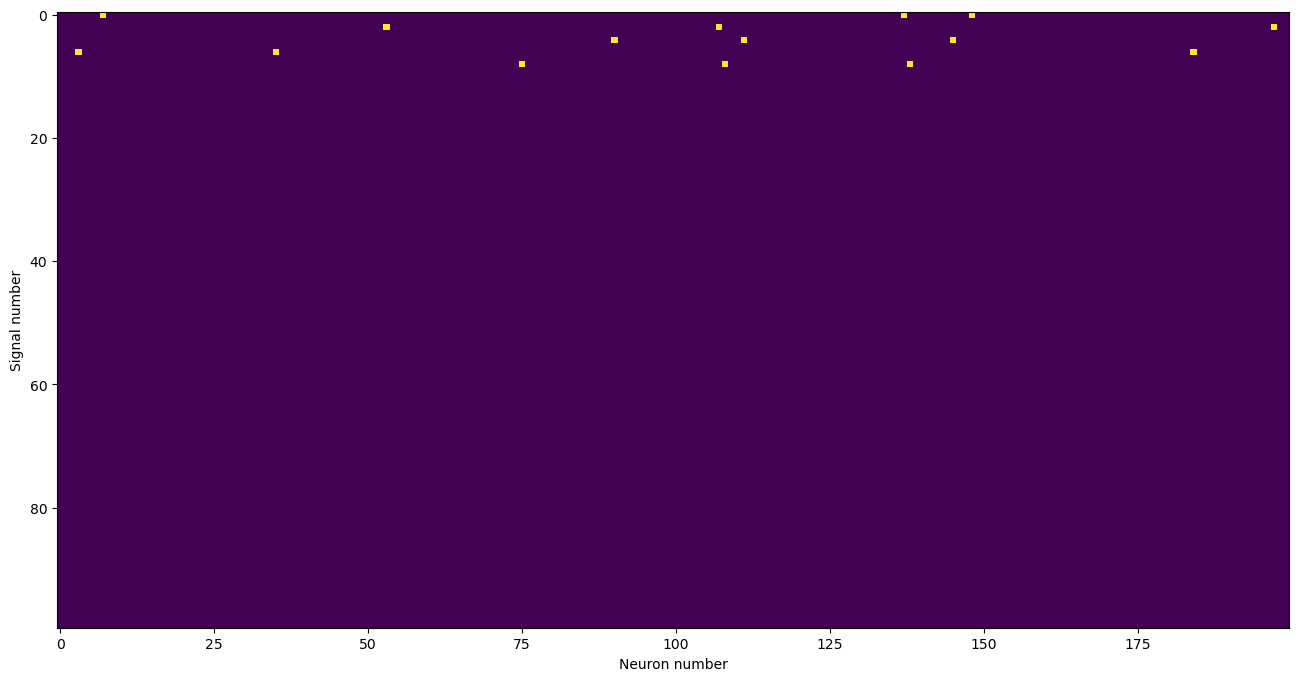

In [19]:
plt.figure(figsize=(20, 8))
plt.imshow(p_values_signficant_after_FDR)
plt.xlabel('Neuron number'); plt.ylabel('Signal number');

::: {.callout-note}

## Examine the figure above. Do you see any dots, indicating significant relationships between neurons and signals after correcting for multiplicity using FDR?

<form id="quiz-form-fdr-dots-pattern">
    <input type="radio" name="answer_fdr_dots_pattern" value="incorrect1"> No, there are no dots indicating significant relationships after FDR correction.<br>
    <input type="radio" name="answer_fdr_dots_pattern" value="incorrect2"> There is one dot, and it is located at a single neuron-signal pair.<br>
    <input type="radio" name="answer_fdr_dots_pattern" value="correct"> There are multiple dots. They are concentrated between signals 0 and 10, and are scattered across neurons.<br>
    <input type="radio" name="answer_fdr_dots_pattern" value="incorrect3"> The dots are evenly spread across all signals and all neurons.<br><br>
    <button type="button" onclick="checkAnswerFdrDotsPattern()">Submit</button>
</form>

<p id="feedback_fdr_dots_pattern"></p>

<script>
function checkAnswerFdrDotsPattern() {
    var selected = document.querySelector('input[name="answer_fdr_dots_pattern"]:checked');
    var feedback = document.getElementById("feedback_fdr_dots_pattern");

    if (!selected) {
        feedback.innerHTML = "Please select an answer.";
        feedback.style.color = "blue";
        return;
    }

    if (selected.value === "correct") {
        feedback.innerHTML = "✅ Correct! There are multiple dots, concentrated between signals 0 and 10, and they are scattered across neurons.";
        feedback.style.color = "green";
    } else if (selected.value === "incorrect1") {
        feedback.innerHTML = "❌ Incorrect. There are multiple dots indicating significant relationships after FDR correction.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect2") {
        feedback.innerHTML = "❌ Incorrect. There is more than one dot, and the pattern is spread across multiple neurons.";
        feedback.style.color = "red";
    } else if (selected.value === "incorrect3") {
        feedback.innerHTML = "❌ Incorrect. The dots are not evenly spread across all signals. They are concentrated between signals 0 and 10.";
        feedback.style.color = "red";
    }
}
</script>

:::

<div class="alert alert-block alert-info">

*Interpretation*:

- We originally corrected for multiplicity using the Bonferroni correction. Following this strict correction, we found no evidence of significanet associations `spikes` and `signals`.

- After correcting for multiplicity using FDR, we now find some neurons in the rat brain are associated with the some signals.

- We return to our collaborators and they confirm that Signals 0-10 corresponds to different measures of the rodent's position and direction.

</div>


<div class="alert alert-block alert-info">

*Relief*

- We've corrected for multiple comparisons using FDR and find a sensible result.

- The results are consistent with the existing theory that neuron's in the brain encode rodent position.
- We find no evidence that neurons in the rodent brain predict stock market prices.
- Using a less strict correction (FDR instead of Bonferroni) we identify significant associations in the data.

</div>

# 7- Split your data to test your conclusions.

(Pending: describe how you can split your data in half to test your conclusions. You take the first half of your data and epxlore. Find the significant relationships. Then test those relationships in the second half.

(Use first half of data, in time)

In [25]:
T = np.shape(spikes)[0];
p_split = compute_p_values(spikes[0:int(T/2),:], signals[0:int(T/2),:])

100%|██████████| 100/100 [00:24<00:00,  4.15it/s]


(Find candidate significant associations)

In [27]:
np.shape(spikes[0:int(T/2)-1,:])

(249, 200)

In [38]:
p_split

array([[2.76298342e-01, 1.93779483e-01, 3.21559511e-01, ...,
        5.83579451e-01, 4.55213251e-01, 9.67559263e-01],
       [7.13627427e-01, 1.96871382e-01, 1.37859754e-01, ...,
        2.29391494e-01, 4.87550873e-01, 2.44911587e-01],
       [9.20386735e-01, 3.49294902e-01, 5.57160646e-01, ...,
        1.25762463e-04, 1.62009782e-03, 5.99855458e-01],
       ...,
       [2.06981589e-02, 1.48315904e-01, 6.60448601e-01, ...,
        4.58320683e-01, 6.51190811e-01, 9.48354359e-02],
       [4.33764831e-01, 3.73249555e-01, 6.59935926e-01, ...,
        1.64988870e-01, 7.00656464e-01, 1.22953709e-01],
       [7.46086224e-01, 7.70883112e-02, 4.26626802e-01, ...,
        1.86698612e-01, 8.32739797e-01, 9.30276589e-01]])

In [41]:
candidate_significant_pairs = (p_split<0.05)
print(sum(candidate_significant_pairs.flatten()))
[i_signals,i_spikes] = np.where(candidate_significant_pairs)

981


(Test these predicted associations in the second half of data)

In [42]:
p_test = np.zeros(np.shape(i_signals))
for index, element in enumerate(i_signals):
    X = signals[int(T/2):, i_signals[index]]       # Predictor variable
    y = spikes[int(T/2):, i_spikes[index]]        # Response variable
    X = sm.add_constant(X)  # Adding a constant column for the intercept
    glm_model = sm.GLM(y, X, family=sm.families.Poisson())
    glm_results = glm_model.fit()
    p_test[index] = glm_results.pvalues[1]

(Identify significant associations)

In [37]:
i0 = np.where(p_test<0.05/np.size(i_signals))
print('Signal', i_signals[i0], ', Spike', i_spikes[i0])

Signal [] , Spike []


In [31]:
np.size(i_signals)

981

In [35]:
i_spikes[index]

189